In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os
import re
import math
import numpy as np
import matplotlib.pyplot as plt

folder = "../results_files_ML/100160TeV_025deg_3FF_180R290h_Black_20peSM_20peBKG_20peTEST_d0600_500ns"

files = [f for f in os.listdir(folder) if f.endswith(".txt")]

pattern = re.compile(
    r"(8inches|mPMT|mpmt)_val_proton_(\d+)_val_gamma_(\d+)\.txt",
    re.IGNORECASE
)

data = {}

for fname in files:
    match = pattern.match(fname)
    if not match:
        continue

    detector, proton, gamma = match.groups()
    detector = detector.lower()
    proton = int(proton)
    gamma = int(gamma)

    key = (proton, gamma)

    if key not in data:
        data[key] = {}

    path = os.path.join(folder, fname)

    x, y = np.loadtxt(path, usecols=(0, 1), unpack=True)

    if "8inches" in detector:
        data[key]["8inches"] = (x, y)
    else:
        data[key]["mpmt"] = (x, y)


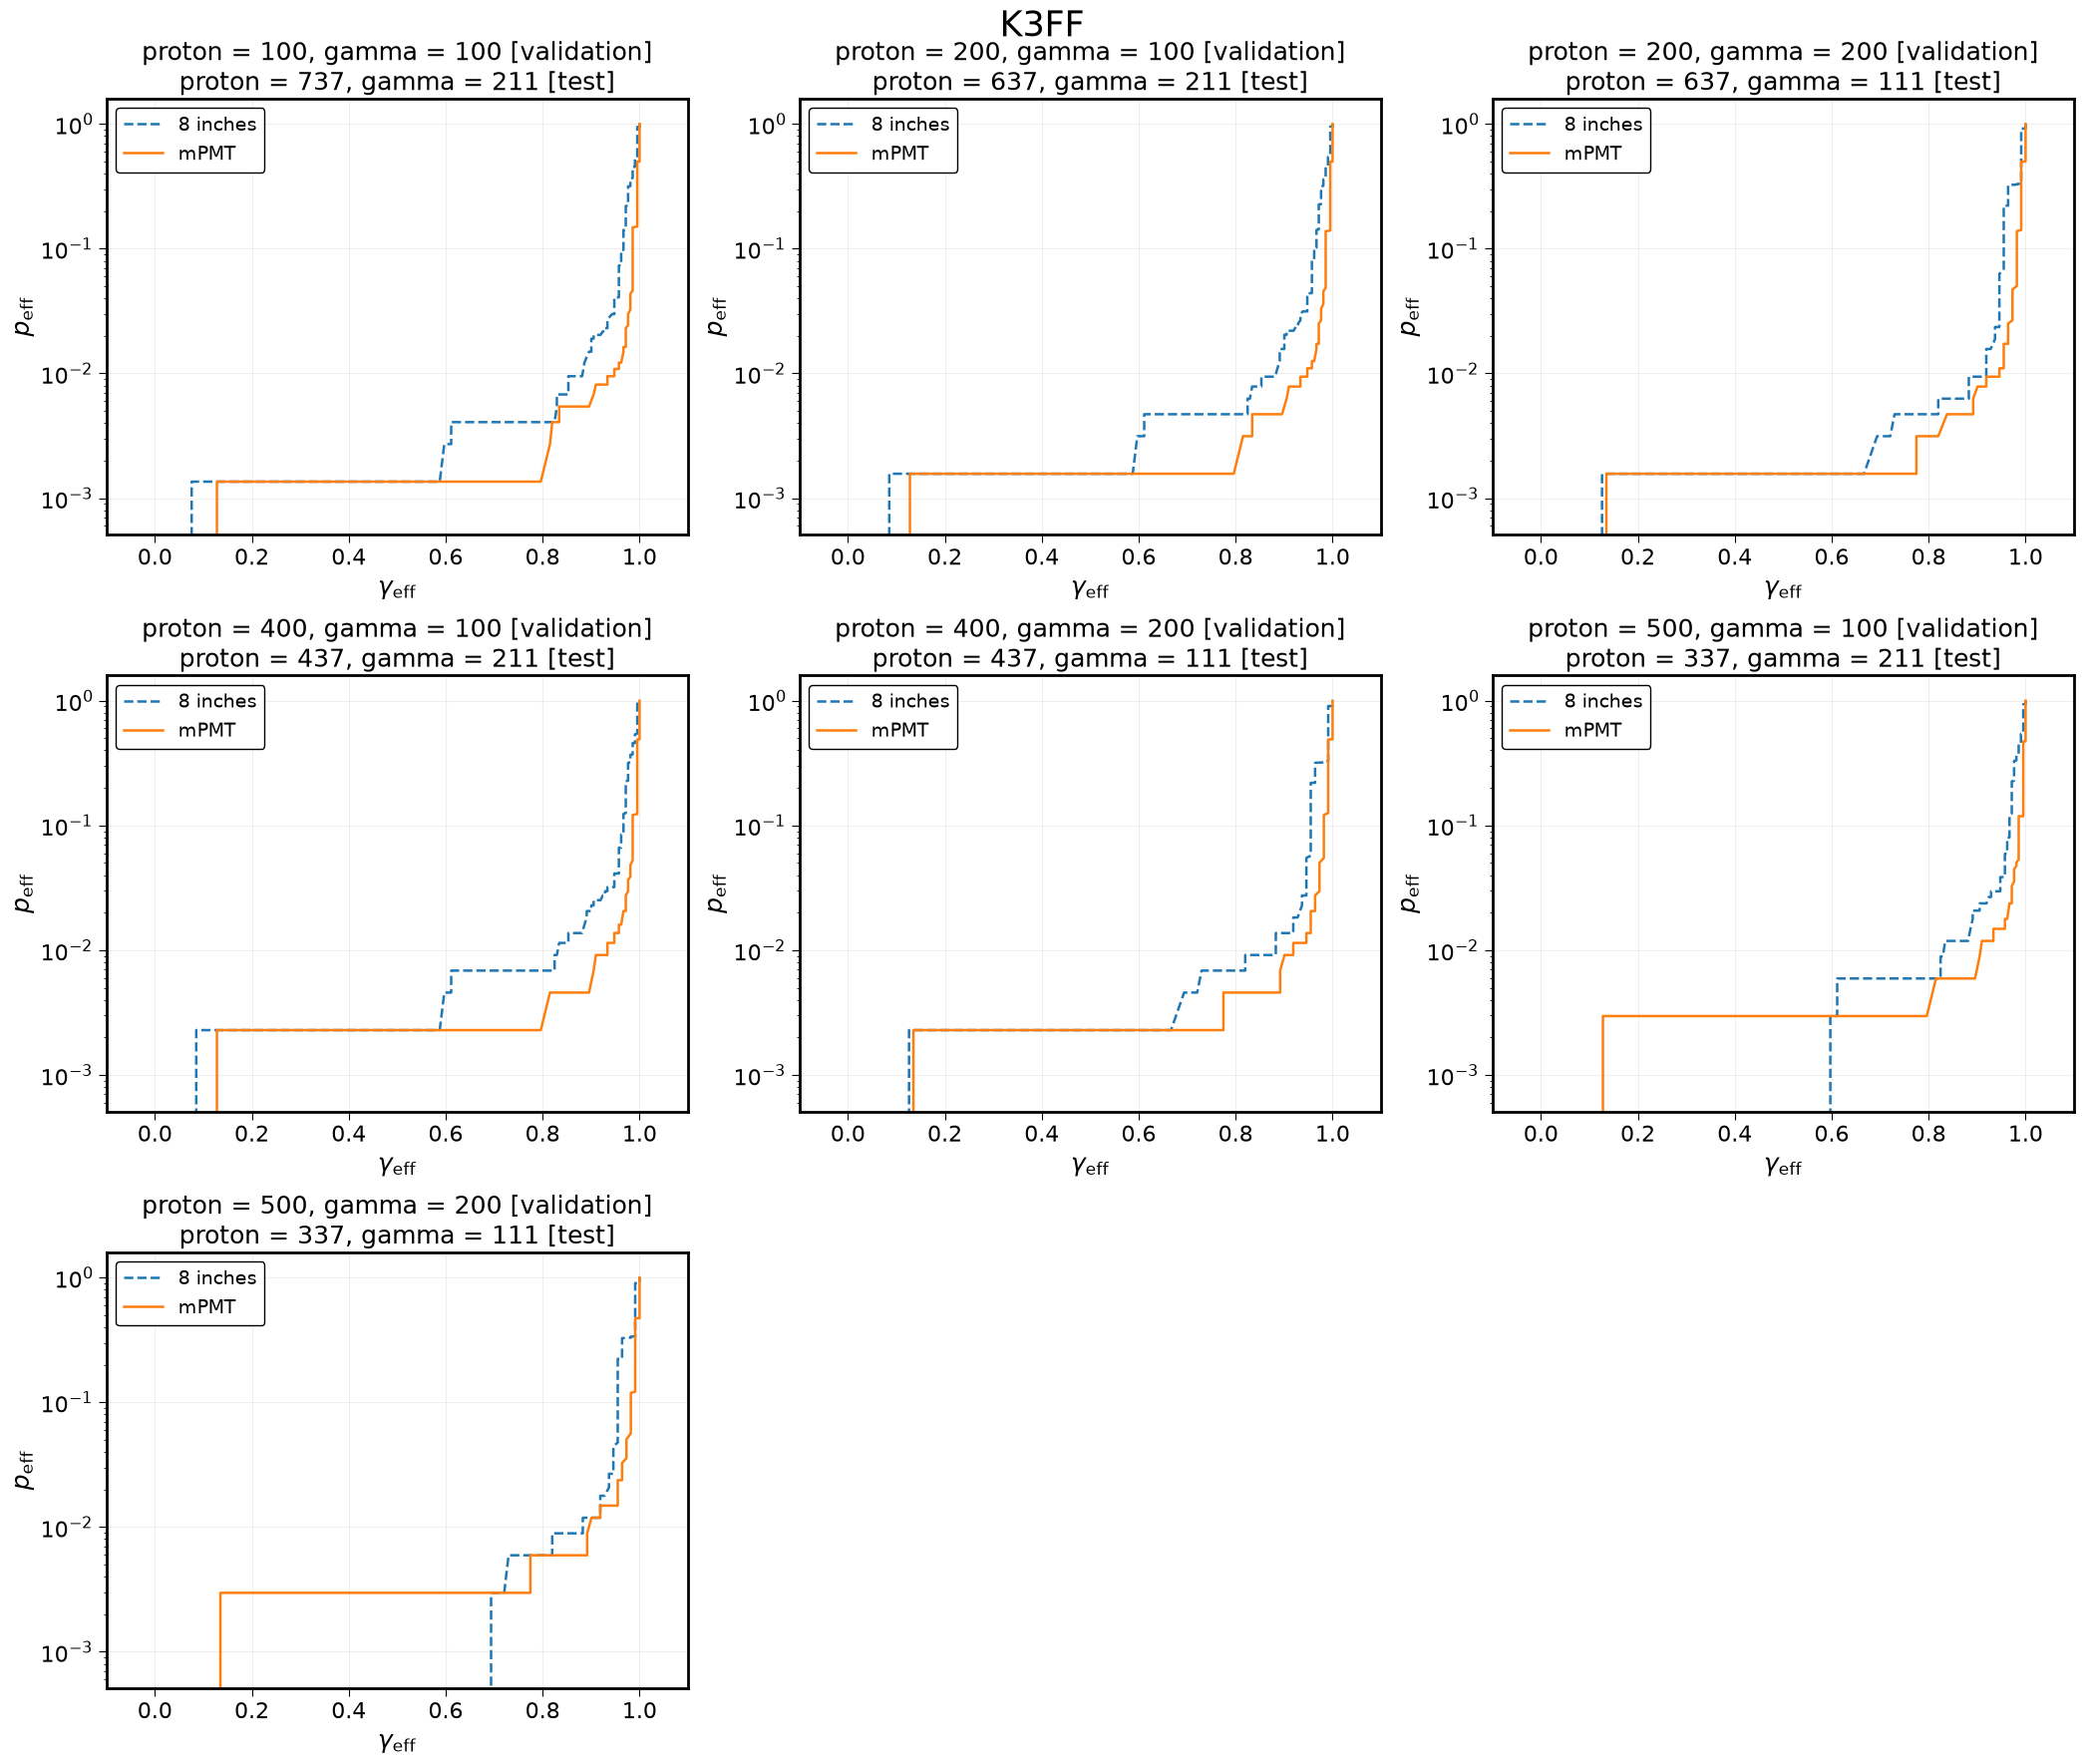

In [4]:
valid_keys = [
    key for key in sorted(data.keys())
    if "8inches" in data[key] and "mpmt" in data[key]
]

nplots = len(valid_keys)
ncols = 3
nrows = math.ceil(nplots / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(7 * ncols, 6 * nrows),
    squeeze=False
)

axes = axes.flatten()

for ax, key in zip(axes, valid_keys):
    proton, gamma = key

    x8, y8 = data[key]["8inches"]
    xm, ym = data[key]["mpmt"]

    ax.plot(x8, y8, lw=1.8, ls="--", label="8 inches")
    ax.plot(xm, ym, lw=1.8, ls="-", label="mPMT")

    for spine in ax.spines.values():
        spine.set_linewidth(2)

    ax.tick_params(axis="both", which="major", labelsize=16, length=6)
    ax.minorticks_off()

    ax.set_xlabel(r"$\gamma_{\mathrm{eff}}$", fontsize=18)
    ax.set_ylabel(r"$p_{\mathrm{eff}}$", fontsize=18)

    ax.set_yscale("log")
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(0.51e-3, 1.6)

    ax.set_xticks([0, 0.20, 0.40, 0.60, 0.80, 1])
    ax.grid(True, alpha=0.2)

    ax.set_title(
        rf"proton = {proton}, gamma = {gamma} [validation]"
        "\n"
        rf"proton = {837 - proton}, gamma = {311 - gamma} [test]",
        fontsize=18
    )

    ax.legend(
        fontsize=14,
        edgecolor="black",
        facecolor="white",
        framealpha=1.0,
        loc="upper left"
    )

for ax in axes[nplots:]:
    ax.axis("off")

plt.suptitle("K3FF", fontsize = 25)
plt.tight_layout()
plt.savefig("../pictures/other/K3ff_validation_comparison.png", dpi = 600)
plt.show()